In [1]:
#Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:
#Load dataset

In [4]:
df = pd.read_csv(r"C:\Users\aashn\Downloads\Mall_Customers.csv")

In [5]:
#First 10 records

In [6]:
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [7]:
#Number of rows and columns

In [8]:
df.shape

(200, 5)

In [9]:
#Identify features

In [10]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [11]:
#Check missing values

In [12]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [13]:
#Descriptive statistics

In [14]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [15]:
#Scatter plot between Annual Income and Spending Score

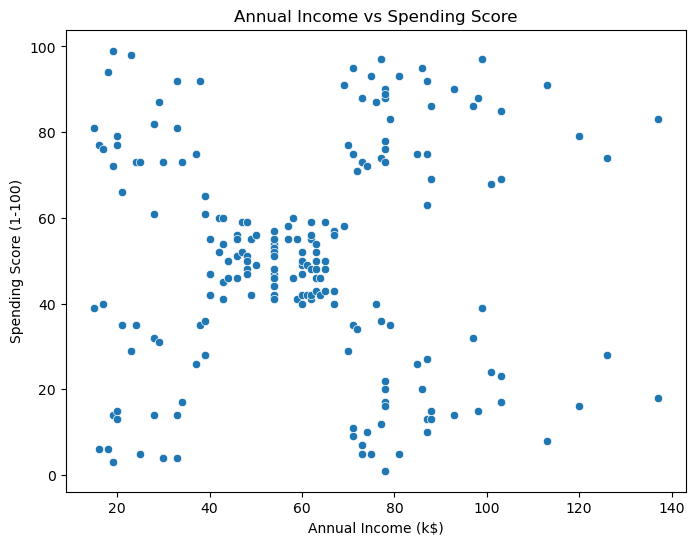

In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)')
plt.title("Annual Income vs Spending Score")
plt.show()

In [17]:
"""
**Observation:**

The scatter plot suggests visible customer groupings. 
Some customers have high income and high spending, some high income and low spending, and similarly for low income groups.
This indicates clustering is appropriate.

"""

'\n**Observation:**\n\nThe scatter plot suggests visible customer groupings. \nSome customers have high income and high spending, some high income and low spending, and similarly for low income groups.\nThis indicates clustering is appropriate.\n\n'

In [18]:
#HISTOGRAMS

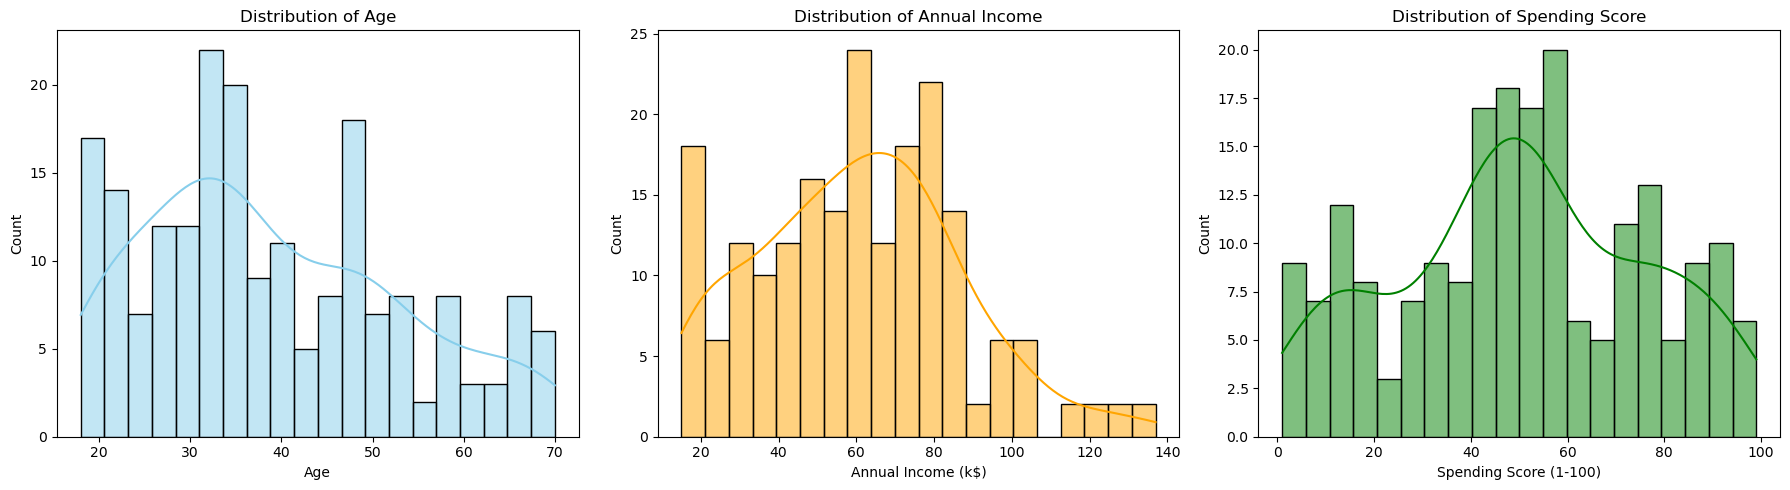

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Distribution of Age")

sns.histplot(df['Annual Income (k$)'], bins=20, kde=True, ax=axes[1], color='orange')
axes[1].set_title("Distribution of Annual Income")

sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True, ax=axes[2], color='green')
axes[2].set_title("Distribution of Spending Score")

plt.tight_layout()
plt.show()


In [20]:
"""
**Interpretation: **

~ Age: Mostly young to middle-aged customers, with fewer elderly customers.
~ Annual Income: Fairly spread, with some concentration in the middle-income range.
~ Spending Score: Broad distribution, showing clear variation in customer spending behavior.

"""

'\n**Interpretation: **\n\n~ Age: Mostly young to middle-aged customers, with fewer elderly customers.\n~ Annual Income: Fairly spread, with some concentration in the middle-income range.\n~ Spending Score: Broad distribution, showing clear variation in customer spending behavior.\n\n'

In [21]:
#Correlation matrix

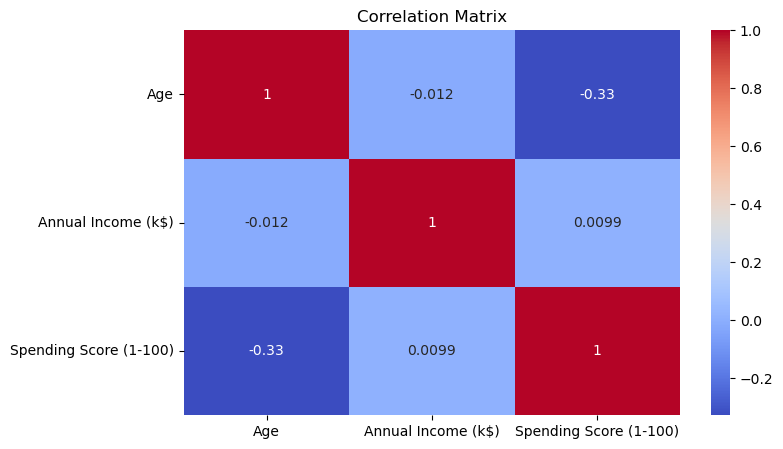

In [22]:
plt.figure(figsize=(8, 5))
corr = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


In [23]:
"""
**Analysis: **
The numerical variables do not show very strong linear correlation. 
That is common in clustering problems, where group structure may still exist visually even without high correlation.

"""

'\n**Analysis: **\nThe numerical variables do not show very strong linear correlation. \nThat is common in clustering problems, where group structure may still exist visually even without high correlation.\n\n'

In [24]:
#Select features for clustering

In [25]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
X.head()


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [26]:
"""
**Why these features are suitable:**

~ They directly reflect customer economic value and buying behavior.
~ They produce clear visual segments.
~ They are easier to interpret for business decisions than using all columns.

"""

'\n**Why these features are suitable:**\n\n~ They directly reflect customer economic value and buying behavior.\n~ They produce clear visual segments.\n~ They are easier to interpret for business decisions than using all columns.\n\n'

In [27]:
#Apply Elbow Method

In [28]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)


In [29]:
#Plot Elbow Curve

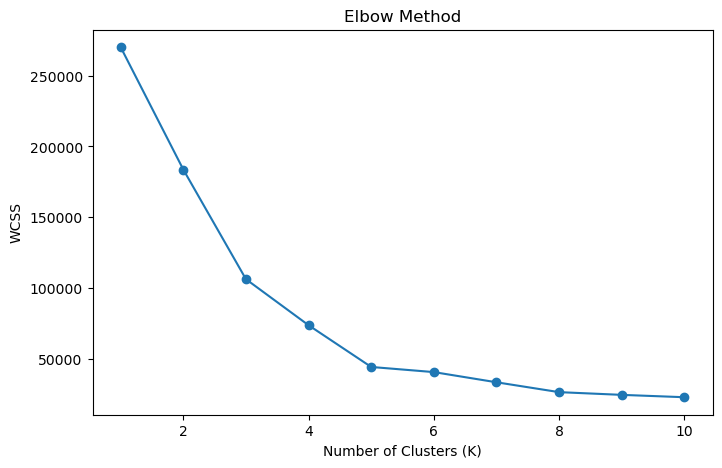

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()


In [31]:
"""
**Why the chosen K is appropriate??**


From this dataset, K = 5 is typically the best choice because the elbow is clearly visible around 5.
After that point, the reduction in WCSS becomes smaller.

We can also validate with silhouette score:

"""

'\n**Why the chosen K is appropriate??**\n\n\nFrom this dataset, K = 5 is typically the best choice because the elbow is clearly visible around 5.\nAfter that point, the reduction in WCSS becomes smaller.\n\nWe can also validate with silhouette score:\n\n'

In [32]:
from sklearn.metrics import silhouette_score

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.3956
K = 3, Silhouette Score = 0.4676
K = 4, Silhouette Score = 0.4938
K = 5, Silhouette Score = 0.5539
K = 6, Silhouette Score = 0.5128
K = 7, Silhouette Score = 0.5017
K = 8, Silhouette Score = 0.4963
K = 9, Silhouette Score = 0.4559
K = 10, Silhouette Score = 0.4426


In [33]:
#Build K-Means model

In [34]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(X)


In [35]:
#Assign cluster labels

In [36]:
df.head(10)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
5,6,Female,22,17,76,2
6,7,Female,35,18,6,4
7,8,Female,23,18,94,2
8,9,Male,64,19,3,4
9,10,Female,30,19,72,2


In [37]:
#Plot clusters and centroids

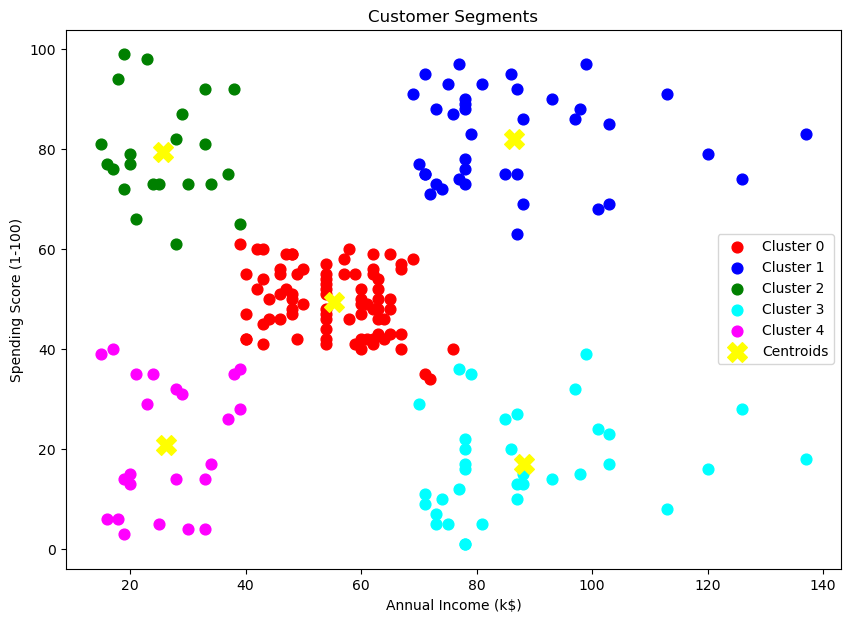

In [38]:
plt.figure(figsize=(10, 7))

colors = ['red', 'blue', 'green', 'cyan', 'magenta']

for i in range(5):
    plt.scatter(
        X[df['Cluster'] == i]['Annual Income (k$)'],
        X[df['Cluster'] == i]['Spending Score (1-100)'],
        s=60,
        c=colors[i],
        label=f'Cluster {i}'
    )

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200,
    c='yellow',
    label='Centroids',
    marker='X'
)

plt.title("Customer Segments")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()


In [39]:
"""
**Interpret groups**

Typical interpretation of the 5 clusters:

~Cluster 1: Low Income - Low Spending
~Cluster 2: Low Income - High Spending
~Cluster 3: High Income - Low Spending
~Cluster 4: High Income - High Spending
~Cluster 5: Average Income - Average Spending

Exact cluster numbers may vary depending on model initialization, so interpret using cluster centers.

Check cluster centers:

"""

'\n**Interpret groups**\n\nTypical interpretation of the 5 clusters:\n\n~Cluster 1: Low Income - Low Spending\n~Cluster 2: Low Income - High Spending\n~Cluster 3: High Income - Low Spending\n~Cluster 4: High Income - High Spending\n~Cluster 5: Average Income - Average Spending\n\nExact cluster numbers may vary depending on model initialization, so interpret using cluster centers.\n\nCheck cluster centers:\n\n'

In [40]:
cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=['Annual Income (k$)', 'Spending Score (1-100)']
)
cluster_centers


,Annual Income (k$),Spending Score (1-100)
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [41]:
#Identify each important cluster

In [42]:
cluster_centers


,Annual Income (k$),Spending Score (1-100)
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [43]:
"""
Then interpret:

High Income - High Spending -> premium / loyal customers
High Income - Low Spending -> under-engaged wealthy customers
Low Income - High Spending -> enthusiastic but budget-limited customers
Low Income - Low Spending -> low-value customers

"""

'\nThen interpret:\n\nHigh Income - High Spending -> premium / loyal customers\nHigh Income - Low Spending -> under-engaged wealthy customers\nLow Income - High Spending -> enthusiastic but budget-limited customers\nLow Income - Low Spending -> low-value customers\n\n'

In [44]:
"""
**Most valuable segment**

High Income - High Spending customers are the most valuable because they have both strong purchasing power and strong spending behavior.

"""

'\n**Most valuable segment**\n\nHigh Income - High Spending customers are the most valuable because they have both strong purchasing power and strong spending behavior.\n\n'

In [45]:
"""
**Greatest growth opportunity**

High Income - Low Spending customers offer the greatest growth opportunity. 
They can afford more, but are not yet spending much. 
With targeted offers, personalization, and engagement, they may be converted into high-value customers.

"""

'\n**Greatest growth opportunity**\n\nHigh Income - Low Spending customers offer the greatest growth opportunity. \nThey can afford more, but are not yet spending much. \nWith targeted offers, personalization, and engagement, they may be converted into high-value customers.\n\n'

In [46]:
"""
**One marketing strategy for each cluster**

~High Income - High Spending: Loyalty rewards, exclusive memberships, premium recommendations
~High Income - Low Spending: Personalized promotions and premium product awareness
~Low Income - High Spending: Discounts, bundle offers, and seasonal campaigns
~Low Income - Low Spending: Basic awareness campaigns and entry-level offers
~Average Income - Average Spending: Cross-selling and retention campaigns

"""

'\n**One marketing strategy for each cluster**\n\n~High Income - High Spending: Loyalty rewards, exclusive memberships, premium recommendations\n~High Income - Low Spending: Personalized promotions and premium product awareness\n~Low Income - High Spending: Discounts, bundle offers, and seasonal campaigns\n~Low Income - Low Spending: Basic awareness campaigns and entry-level offers\n~Average Income - Average Spending: Cross-selling and retention campaigns\n\n'

In [47]:
"""
**Summary of insights**


K-Means clustering divides mall customers into meaningful groups based on Annual Income and Spending Score.

The analysis shows that customers differ significantly in purchasing behavior, allowing businesses to identify valuable, 
low-performing, and growth-potential segments.

"""

'\n**Summary of insights**\n\n\nK-Means clustering divides mall customers into meaningful groups based on Annual Income and Spending Score.\n\nThe analysis shows that customers differ significantly in purchasing behavior, allowing businesses to identify valuable, \nlow-performing, and growth-potential segments.\n\n'

In [48]:
"""
**How businesses use these clusters**

Businesses can use these clusters for:

~targeted promotions
~customer retention strategies
~product recommendations
~pricing decisions
~loyalty programs
~efficient marketing budget allocation

"""

'\n**How businesses use these clusters**\n\nBusinesses can use these clusters for:\n\n~targeted promotions\n~customer retention strategies\n~product recommendations\n~pricing decisions\n~loyalty programs\n~efficient marketing budget allocation\n\n'

In [49]:
"""
**Advantages and limitations of K-Means**



Advantages

Simple and easy to implement
Fast for large datasets
Produces clear segments
Easy to visualize and interpret

Limitations

Must choose K in advance
Sensitive to outliers
Works best for roughly spherical clusters
Results may vary with initialization
Not ideal for complex, overlapping customer behavior patterns

"""

'\n**Advantages and limitations of K-Means**\n\n\n\nAdvantages\n\nSimple and easy to implement\nFast for large datasets\nProduces clear segments\nEasy to visualize and interpret\n\nLimitations\n\nMust choose K in advance\nSensitive to outliers\nWorks best for roughly spherical clusters\nResults may vary with initialization\nNot ideal for complex, overlapping customer behavior patterns\n\n'

In [50]:
import pickle

with open('kmeans_model.pkl', 'wb') as file:
    pickle.dump(kmeans, file)

print("Model saved successfully!")

Model saved successfully!


In [51]:
import pickle

with open('kmeans_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

print("Model loaded successfully!")

Model loaded successfully!


In [52]:
income = float(input("Enter Annual Income (k$): "))
score = float(input("Enter Spending Score (1-100): "))

prediction = loaded_model.predict([[income, score]])

print("Predicted Cluster:", prediction[0])

Enter Annual Income (k$):  10000
Enter Spending Score (1-100):  67


Predicted Cluster: 3


In [53]:
income = float(input("Enter Annual Income (k$): "))
score = float(input("Enter Spending Score (1-100): "))

prediction = loaded_model.predict([[income, score]])

segment_names = {
    0: "Cluster 0",
    1: "Cluster 1",
    2: "Cluster 2",
    3: "Cluster 3",
    4: "Cluster 4"
}

print("Predicted Customer Segment:", segment_names[prediction[0]])

Enter Annual Income (k$):  10000
Enter Spending Score (1-100):  66


Predicted Customer Segment: Cluster 3


In [54]:
segment_names = {
    0: "High Income - High Spending",
    1: "Low Income - Low Spending",
    2: "High Income - Low Spending",
    3: "Low Income - High Spending",
    4: "Average Customers"
}

In [55]:
income = float(input("Enter Annual Income (k$): "))
score = float(input("Enter Spending Score (1-100): "))

prediction = loaded_model.predict([[income, score]])

print("\nCustomer Segment:")
print(segment_names[prediction[0]])

Enter Annual Income (k$):  1000
Enter Spending Score (1-100):  23



Customer Segment:
Low Income - High Spending
